# 업로드 주기 불확실성 점수

## 전체 위험도 프레임워크에서의 위치
```
최종 위험도 (ABCDF)
├── 평판 위험도 33%   댓글 감성 지수 + 민감 키워드 매칭도
├── 트래픽 위험도 33% 이탈 확률 + 정체 확률 + 조회수 변동성 + [업로드 주기 불확실성 ← 현재]
└── 팬덤 위험도 33%   활성 시청자 비율 + 시청 유지 안정성
```

## 설계 원칙
> **30일마다 꾸준히 올리는 채널 → 높은 점수**  
> **업로드 간격이 들쭉날쭉한 채널 → 낮은 점수**

점수가 **높을수록 안정적**, **낮을수록 불확실**합니다.  
(다른 위험도 지표들과 합산 시 `1 - regularity_score`로 변환해서 사용하세요.)

## 핵심 설계: CV만으로 부족한 이유

| 채널 | 평균 간격 | CV | 문제 |
|---|---|---|---|
| 전여옥TV | 0.2일 | 2.58 | 매일 올리는 채널인데 CV가 높게 나옴 — 짧은 간격에서 CV 뻥튀기 |
| 김국진TV | 6.0일 | 0.21 | 규칙적으로 잘 잡힘 |
| SONa | 87.6일 | 2.50 | 진짜 불규칙 — 잘 잡힘 |

→ **CV + 간격 일관성(이상치 비율) + 최대 공백 패널티**를 결합합니다.


## 0. 라이브러리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

print("라이브러리 로드 완료")


라이브러리 로드 완료


In [2]:
# 폰트
import matplotlib.pyplot as plt

# macOS에서 가장 많이 사용하는 설정
plt.rcParams["font.family"] = "AppleGothic" # 혹은 "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

print("macOS 한글 폰트 설정 완료")

macOS 한글 폰트 설정 완료


## 1. 데이터 로드

In [2]:
long = pd.read_csv("../../data/raw/filtered_dataset_long.csv")
long["published_at"] = pd.to_datetime(long["published_at"], utc=True, errors="coerce")
long = long.dropna(subset=["published_at"])
long = long.sort_values(["channel_id", "published_at"]).reset_index(drop=True)

print(f"long shape : {long.shape}")
print(f"채널 수    : {long['channel_id'].nunique()}")


long shape : (166445, 18)
채널 수    : 3336


## 2. 규칙성 점수 계산 로직

### 구성 요소 3가지

| 구성 요소 | 가중치 | 설명 |
|---|---|---|
| **CV 안정성** | 50% | 변동계수(std/mean)가 낮을수록 규칙적. 단, 평균 간격이 매우 짧은 채널은 보정 |
| **이상치 비율** | 30% | 평균 ± 1.5σ 바깥 구간 비율 — 낮을수록 튀는 간격이 없음 |
| **최대 공백 패널티** | 20% | max_gap이 평균 간격의 N배를 초과하면 감점 |

### 최종 점수
```
regularity_score = CV안정성×0.5 + 이상치안정성×0.3 + 공백안정성×0.2
```
값이 높을수록(→ 1) 규칙적, 낮을수록(→ 0) 불확실합니다.


In [3]:
def calc_regularity_score(group):
    g = group.sort_values("published_at")
    dates = g["published_at"].dropna().tolist()

    # 업로드 간격 (일) 계산
    intervals = [(dates[i+1] - dates[i]).days for i in range(len(dates) - 1)]

    if len(intervals) < 3:
        return None

    mean_iv = np.mean(intervals)
    std_iv  = np.std(intervals)
    max_iv  = max(intervals)

    # ── ① CV 안정성 ──────────────────────────────────────────────────────────
    # CV = std / mean. 0에 가까울수록 규칙적
    # 단, 평균 간격이 1일 미만이면 CV가 과장됨 → mean을 최소 1로 보정
    mean_adj = max(mean_iv, 1.0)
    cv = std_iv / mean_adj

    # CV → 0~1 안정성 점수 변환
    # CV=0 → 1.0(완벽), CV=1 → 0.5, CV=2 → 0.25, CV≥3 → ≈0
    cv_stability = 1 / (1 + cv)

    # ── ② 이상치 비율 ─────────────────────────────────────────────────────────
    # 평균 ± 1.5σ 범위를 벗어난 간격의 비율
    lower = mean_iv - 1.5 * std_iv
    upper = mean_iv + 1.5 * std_iv
    outlier_ratio = np.mean([1 if (iv < lower or iv > upper) else 0
                             for iv in intervals])
    outlier_stability = 1 - outlier_ratio   # 낮은 이상치 비율 → 높은 안정성

    # ── ③ 최대 공백 패널티 ────────────────────────────────────────────────────
    # max_gap이 평균 간격의 몇 배인지 측정
    # 3배 이내 → 패널티 없음(1.0), 10배 이상 → 패널티 최대(0.0)
    gap_ratio = max_iv / (mean_adj)
    gap_stability = np.clip(1 - (gap_ratio - 3) / 7, 0, 1)
    # gap_ratio=3 → 1.0, gap_ratio=10 → 0.0, gap_ratio>10 → 0.0

    # ── 최종 점수 (가중 합산) ─────────────────────────────────────────────────
    regularity_score = (
        cv_stability      * 0.5 +
        outlier_stability * 0.3 +
        gap_stability     * 0.2
    )

    return pd.Series({
        "mean_interval_days" : round(mean_iv, 1),
        "std_interval_days"  : round(std_iv, 1),
        "max_gap_days"       : max_iv,
        "cv"                 : round(cv, 3),
        "cv_stability"       : round(cv_stability, 4),
        "outlier_ratio"      : round(outlier_ratio, 4),
        "outlier_stability"  : round(outlier_stability, 4),
        "gap_ratio"          : round(gap_ratio, 2),
        "gap_stability"      : round(gap_stability, 4),
        "regularity_score"   : round(float(regularity_score), 4),
    })

score_df = long.groupby("channel_id").apply(
    calc_regularity_score, include_groups=False
).dropna(how="all").reset_index()

# 채널명 붙이기
titles = long.groupby("channel_id")["channel_title"].first().reset_index()
score_df = score_df.merge(titles, on="channel_id")

print(f"채널 수: {len(score_df)}")
print()
print("=== regularity_score 분포 ===")
print(score_df["regularity_score"].describe().round(3))


채널 수: 3333

=== regularity_score 분포 ===
count    3333.000
mean        0.624
std         0.159
min         0.358
25%         0.466
50%         0.638
75%         0.754
max         1.000
Name: regularity_score, dtype: float64


## 3. 점수 검증

30일 간격 꾸준한 채널이 실제로 높은 점수를 받는지 시뮬레이션으로 확인합니다.


In [4]:
# 가상 채널 시뮬레이션
test_cases = {
    "매일 꾸준 (1일)" : [1]*30,
    "주 1회 꾸준 (7일)": [7]*20,
    "월 1회 꾸준 (30일)": [30]*15,
    "불규칙 (평균 30일)": [5,60,3,90,7,45,2,80,10,55,3,70],
    "가끔 폭발적 공백"  : [7,7,7,7,7,7,7,7,7,7,7,180,7,7,7],
    "완전 랜덤"        : [1,90,3,60,14,2,45,7,120,5],
}

print(f"{'케이스':25s}  {'평균':>6}일  {'CV':>6}  {'이상치':>6}  {'gap배수':>7}  {'점수':>6}")
print("-" * 70)

for name, ivs in test_cases.items():
    mean_iv  = np.mean(ivs)
    std_iv   = np.std(ivs)
    mean_adj = max(mean_iv, 1.0)
    cv       = std_iv / mean_adj
    cv_stab  = 1 / (1 + cv)
    lower, upper = mean_iv - 1.5*std_iv, mean_iv + 1.5*std_iv
    out_r    = np.mean([1 if (v<lower or v>upper) else 0 for v in ivs])
    out_stab = 1 - out_r
    gap_r    = max(ivs) / mean_adj
    gap_stab = float(np.clip(1-(gap_r-3)/7, 0, 1))
    score    = cv_stab*0.5 + out_stab*0.3 + gap_stab*0.2
    print(f"{name:25s}  {mean_iv:>6.1f}일  {cv:>6.3f}  {out_r:>6.2f}  {gap_r:>7.1f}배  {score:>6.3f}")


케이스                            평균일      CV     이상치    gap배수      점수
----------------------------------------------------------------------
매일 꾸준 (1일)                    1.0일   0.000    0.00      1.0배   1.000
주 1회 꾸준 (7일)                  7.0일   0.000    0.00      1.0배   1.000
월 1회 꾸준 (30일)                30.0일   0.000    0.00      1.0배   1.000
불규칙 (평균 30일)                 35.8일   0.913    0.08      2.5배   0.736
가끔 폭발적 공백                    18.5일   2.328    0.07      9.7배   0.438
완전 랜덤                        34.7일   1.166    0.10      3.5배   0.688


## 4. 채널별 점수 결과

In [5]:
result = score_df[[
    "channel_id", "channel_title", "regularity_score",
    "mean_interval_days", "std_interval_days", "max_gap_days",
    "cv", "outlier_ratio", "gap_ratio",
    "cv_stability", "outlier_stability", "gap_stability",
]].sort_values("regularity_score", ascending=False).reset_index(drop=True)

print("=== 업로드 주기 규칙성 점수 (높을수록 규칙적) ===")
print(result[[
    "channel_title","regularity_score",
    "mean_interval_days","cv","outlier_ratio","max_gap_days"
]].to_string(index=False))


=== 업로드 주기 규칙성 점수 (높을수록 규칙적) ===
                            channel_title  regularity_score  mean_interval_days    cv  outlier_ratio  max_gap_days
                                      킥튜브            1.0000                 0.0 0.000         0.0000           0.0
                                 여의도 육퇴클럽            1.0000                 0.0 0.000         0.0000           0.0
                                  김성룡 바둑랩            1.0000                 0.0 0.000         0.0000           0.0
                              픽잇 :Pick it            1.0000                 0.0 0.000         0.0000           0.0
            Disney Plus Korea 디즈니 플러스 코리아            1.0000                 0.0 0.000         0.0000           0.0
                                     꺼리튜브            1.0000                 0.0 0.000         0.0000           0.0
                                휴먼다큐 사노라면            1.0000                 0.0 0.000         0.0000           0.0
                                    오늘비와?      

## 5. 시각화

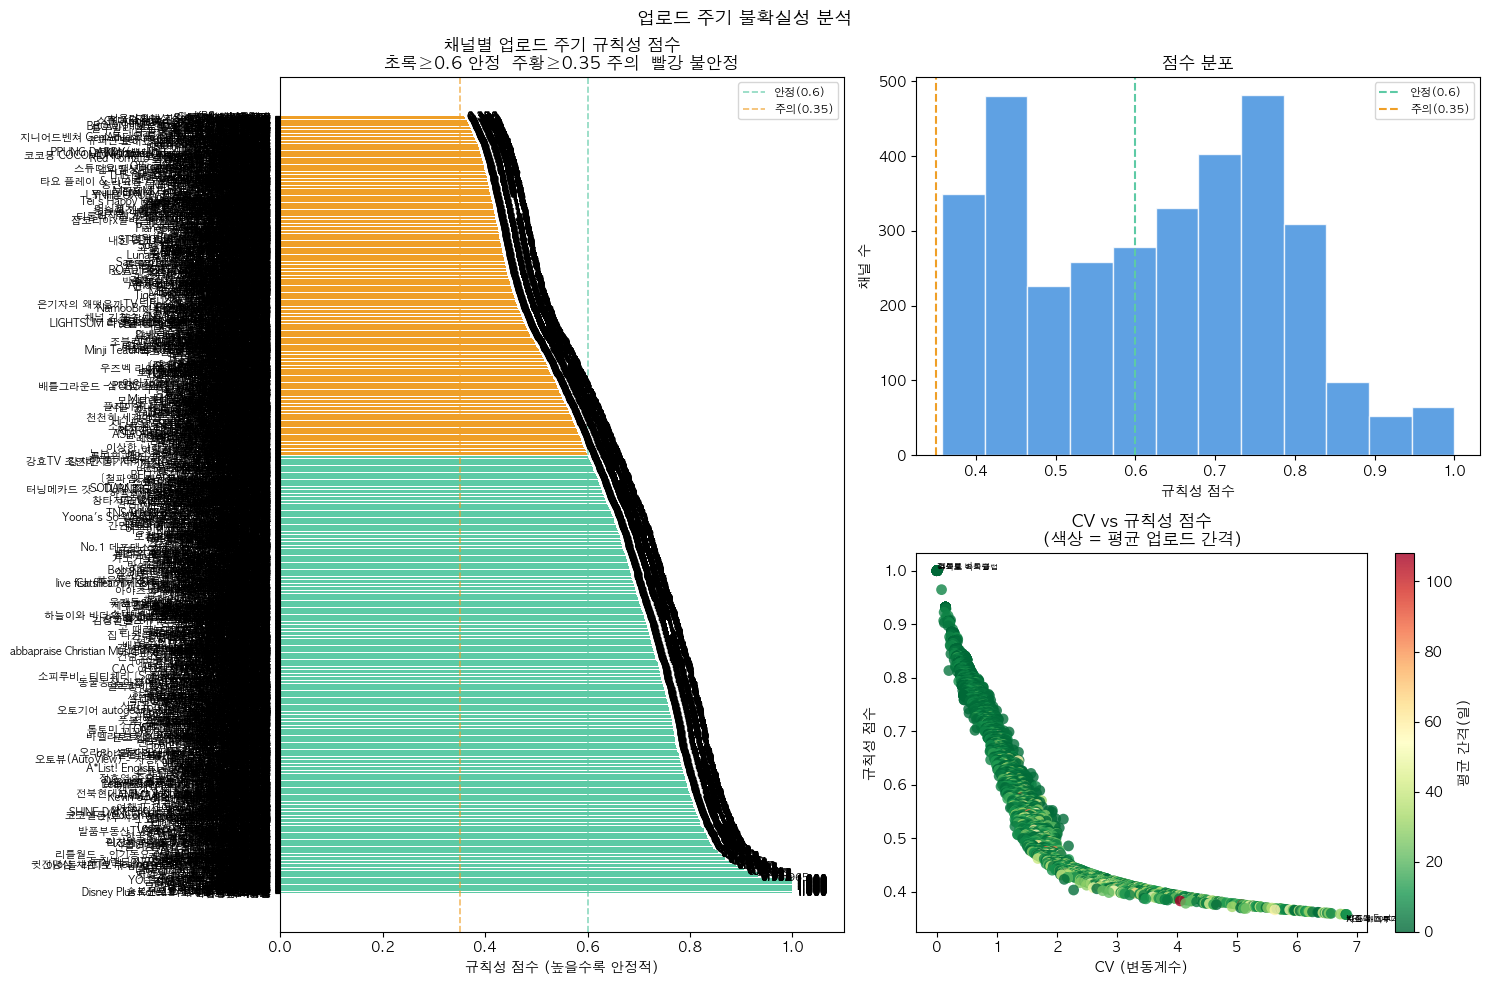

In [7]:
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# ── ① 채널별 점수 바차트 ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[:, 0])
colors = [
    "#5DCAA5" if v >= 0.6 else
    "#EF9F27" if v >= 0.35 else
    "#D85A30"
    for v in result["regularity_score"]
]
ax1.barh(result["channel_title"], result["regularity_score"],
         color=colors, edgecolor="none")
for i, v in enumerate(result["regularity_score"]):
    ax1.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=7.5)
ax1.axvline(0.6,  color="#5DCAA5", linestyle="--", lw=1.2, alpha=0.7, label="안정(0.6)")
ax1.axvline(0.35, color="#EF9F27", linestyle="--", lw=1.2, alpha=0.7, label="주의(0.35)")
ax1.set_xlabel("규칙성 점수 (높을수록 안정적)")
ax1.set_title("채널별 업로드 주기 규칙성 점수\n초록≥0.6 안정  주황≥0.35 주의  빨강 불안정")
ax1.legend(fontsize=8)
ax1.tick_params(axis="y", labelsize=7.5)
ax1.set_xlim(0, 1.1)

# ── ② 점수 분포 히스토그램 ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(result["regularity_score"], bins=12,
         color="#378ADD", edgecolor="white", alpha=0.8)
ax2.axvline(0.6,  color="#5DCAA5", linestyle="--", lw=1.5, label="안정(0.6)")
ax2.axvline(0.35, color="#EF9F27", linestyle="--", lw=1.5, label="주의(0.35)")
ax2.set_xlabel("규칙성 점수"); ax2.set_ylabel("채널 수")
ax2.set_title("점수 분포"); ax2.legend(fontsize=8)

# ── ③ CV vs 점수 산점도 ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
sc = ax3.scatter(
    result["cv"], result["regularity_score"],
    c=result["mean_interval_days"], cmap="RdYlGn_r",
    s=60, alpha=0.8, edgecolors="none"
)
plt.colorbar(sc, ax=ax3, label="평균 간격(일)")
ax3.set_xlabel("CV (변동계수)")
ax3.set_ylabel("규칙성 점수")
ax3.set_title("CV vs 규칙성 점수\n(색상 = 평균 업로드 간격)")

# 채널명 레이블 (상하위 5개)
for _, row in result.head(3).iterrows():
    ax3.annotate(row["channel_title"][:8], (row["cv"], row["regularity_score"]),
                 fontsize=6, ha="left", va="bottom")
for _, row in result.tail(3).iterrows():
    ax3.annotate(row["channel_title"][:8], (row["cv"], row["regularity_score"]),
                 fontsize=6, ha="left", va="top")

plt.suptitle("업로드 주기 불확실성 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [6]:
# 점수 구간별 채널 수
stable   = (result["regularity_score"] >= 0.6).sum()
caution  = ((result["regularity_score"] >= 0.35) & (result["regularity_score"] < 0.6)).sum()
unstable = (result["regularity_score"] < 0.35).sum()

print(f"안정   (0.60~1.00): {stable:>3}개 채널")
print(f"주의   (0.35~0.60): {caution:>3}개 채널")
print(f"불안정 (0.00~0.35): {unstable:>3}개 채널")


안정   (0.60~1.00): 1872개 채널
주의   (0.35~0.60): 1461개 채널
불안정 (0.00~0.35):   0개 채널


## 6. 안정 vs 불안정 채널 업로드 패턴 비교

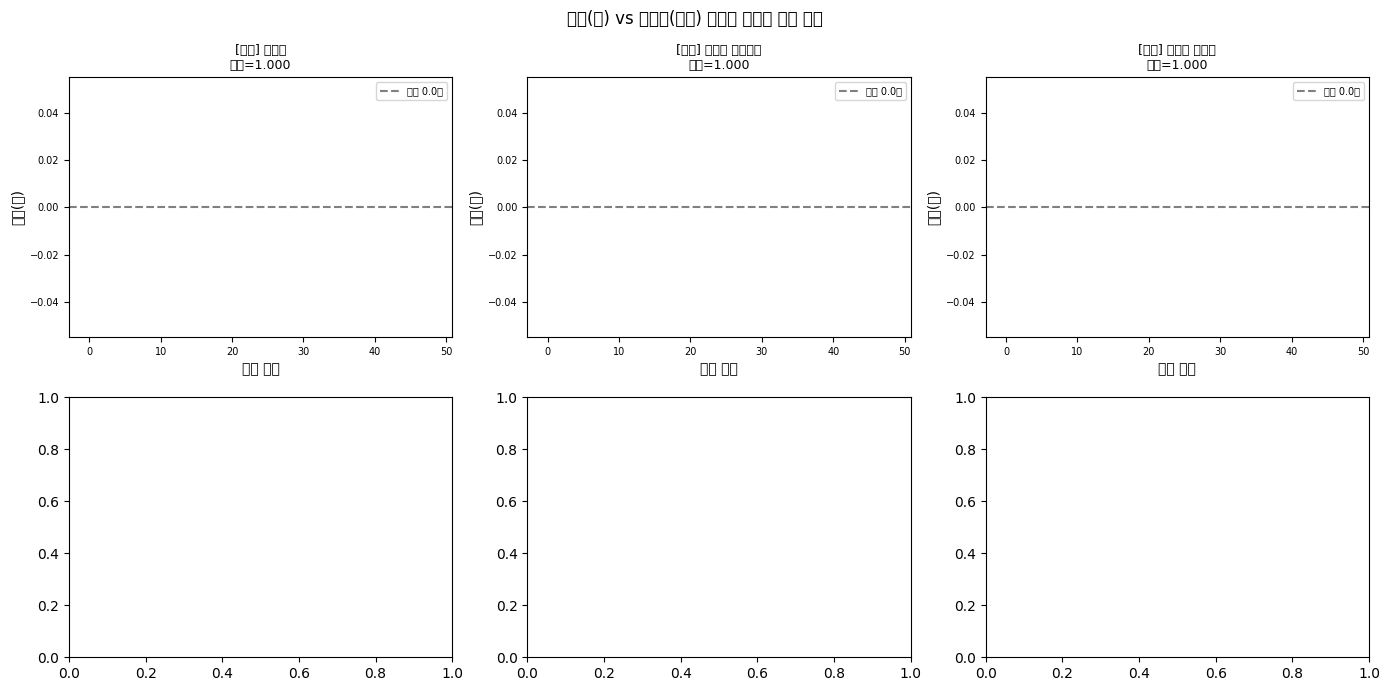

In [7]:
stable_ids   = result[result["regularity_score"] >= 0.6]["channel_id"].tolist()[:3]
unstable_ids = result[result["regularity_score"] <  0.35]["channel_id"].tolist()[:3]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("안정(위) vs 불안정(아래) 채널의 업로드 간격 패턴", fontsize=12)

for i, (cid, ax) in enumerate(zip(stable_ids + unstable_ids, axes.flatten())):
    g = long[long["channel_id"] == cid].sort_values("published_at")
    dates = g["published_at"].tolist()
    ivs   = [(dates[j+1]-dates[j]).days for j in range(len(dates)-1)]
    score = result[result["channel_id"] == cid]["regularity_score"].values[0]
    title = g["channel_title"].iloc[0][:15]

    color = "#5DCAA5" if i < 3 else "#D85A30"
    ax.bar(range(len(ivs)), ivs, color=color, alpha=0.7, edgecolor="none")
    ax.axhline(np.mean(ivs), color="gray", linestyle="--", lw=1.5,
               label=f"평균 {np.mean(ivs):.1f}일")
    ax.set_title(f"{'[안정]' if i<3 else '[불안정]'} {title}\n점수={score:.3f}", fontsize=9)
    ax.set_xlabel("영상 순서"); ax.set_ylabel("간격(일)")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


## 7. 저장

In [8]:
output = result[[
    "channel_id", "channel_title", "regularity_score",
    "mean_interval_days", "std_interval_days", "max_gap_days",
    "cv", "outlier_ratio", "gap_ratio",
]].copy()

output.to_csv("../../data/raw/upload_regularity_score.csv", index=False, encoding="utf-8-sig")
print("저장 완료: upload_regularity_score.csv")
print()
print("=== 최종 출력 ===")
print(output[["channel_title","regularity_score","mean_interval_days","cv","max_gap_days"]]
      .to_string(index=False))


저장 완료: upload_regularity_score.csv

=== 최종 출력 ===
                            channel_title  regularity_score  mean_interval_days    cv  max_gap_days
                                      킥튜브            1.0000                 0.0 0.000           0.0
                                 여의도 육퇴클럽            1.0000                 0.0 0.000           0.0
                                  김성룡 바둑랩            1.0000                 0.0 0.000           0.0
                              픽잇 :Pick it            1.0000                 0.0 0.000           0.0
            Disney Plus Korea 디즈니 플러스 코리아            1.0000                 0.0 0.000           0.0
                                     꺼리튜브            1.0000                 0.0 0.000           0.0
                                휴먼다큐 사노라면            1.0000                 0.0 0.000           0.0
                                    오늘비와?            1.0000                 0.0 0.000           0.0
                        전쓰트의 게임 채널 Junsst         

## 점수 해석 & 통합 가이드

### 점수 구간별 의미
| 점수 | 등급 | 의미 |
|---|---|---|
| 0.60 ~ 1.00 | 안정 | 꾸준한 업로드. 간격이 30일이어도 규칙적이면 안정 |
| 0.35 ~ 0.60 | 주의 | 가끔 긴 공백 발생. 모니터링 필요 |
| 0.00 ~ 0.35 | 불안정 | 업로드 주기 예측 불가. 트래픽 위험 높음 |

### 트래픽 위험도에 통합 시
이 점수는 **규칙성**을 측정하므로, 위험도 합산 시 반전이 필요합니다.

```python
# 트래픽 위험도 합산 예시
upload_risk = 1 - regularity_score   # 불확실성 위험도로 변환

traffic_risk = (
    churn_prob        * 0.25 +   # 이탈 확률
    stagnation_prob   * 0.25 +   # 정체 확률
    view_volatility   * 0.25 +   # 조회수 변동성 (미구현)
    upload_risk       * 0.25     # 업로드 주기 불확실성
)
```
